In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [35]:
# ============================================================
# TASK 1 — NAV TREND ANALYSIS
# Load and prepare NAV data
# ============================================================

nav_history = pd.read_csv("../data/raw/nav_history.csv")

nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_history["nav"] = pd.to_numeric(
    nav_history["nav"],
    errors="coerce"
)

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("=" * 70)
print("NAV DATA — EDA")
print("=" * 70)

print("\nShape:", nav_history.shape)

print("\nColumns:")
print(nav_history.columns.tolist())

print("\nNumber of schemes:")
print(nav_history["amfi_code"].nunique())

print("\nDate range:")
print("Start:", nav_history["date"].min())
print("End:", nav_history["date"].max())

print("\nMissing values:")
display(nav_history.isnull().sum())

print("\nFirst 10 records:")
display(nav_history.head(10))

NAV DATA — EDA

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Number of schemes:
40

Date range:
Start: 2022-01-03 00:00:00
End: 2026-05-29 00:00:00

Missing values:


amfi_code    0
date         0
nav          0
dtype: int64


First 10 records:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [36]:
# ============================================================
# TASK 1 — DAILY NAV TREND FOR ALL 40 SCHEMES
# ============================================================

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend — All 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700,
    hovermode="x unified",
    legend_title_text="AMFI Code"
)

fig.show()

In [37]:
# ============================================================
# TASK 1 — HIGHLIGHT 2023 BULL RUN & 2024 CORRECTION
# ============================================================

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend — 2022–2026",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    fillcolor="green",
    opacity=0.12,
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    fillcolor="red",
    opacity=0.12,
    line_width=0
)

fig.update_layout(
    template="plotly_white",
    height=700,
    hovermode="x unified",
    legend_title_text="AMFI Code"
)

fig.show()

In [38]:
# ============================================================
# TASK 2 — AUM GROWTH BY FUND HOUSE
# Load and prepare AUM data
# ============================================================

aum = pd.read_csv(
    "../data/raw/aum_by_fund_house.csv"
)

print("=" * 70)
print("AUM DATA — EDA")
print("=" * 70)

print("\nShape:", aum.shape)

print("\nColumns:")
print(aum.columns.tolist())

print("\nFirst 10 rows:")
display(aum.head(10))

print("\nData types:")
print(aum.dtypes)

print("\nMissing values:")
display(aum.isnull().sum())

AUM DATA — EDA

Shape: (90, 5)

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

First 10 rows:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88



Data types:
date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

Missing values:


date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [39]:
# ============================================================
# TASK 2 — AUM GROWTH
# Check the actual column names
# ============================================================

print("AUM Dataset Columns:")
print(aum.columns.tolist())

print("\nAUM Dataset Shape:")
print(aum.shape)

print("\nFirst 10 Rows:")
display(aum.head(10))

AUM Dataset Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

AUM Dataset Shape:
(90, 5)

First 10 Rows:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [40]:
# ============================================================
# TASK 2 — AUM GROWTH BY FUND HOUSE
# Grouped bar chart: 2022–2025
# ============================================================

# Keep only the required years
aum_2022_2025 = aum[
    aum["year"].between(2022, 2025)
].copy()

# Create the grouped bar chart
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_2022_2025,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

KeyError: 'year'

In [ ]:
# ============================================================
# TASK 2 — HIGHLIGHT SBI DOMINANCE
# ============================================================

# Find SBI's highest AUM value
sbi_data = aum_2022_2025[
    aum_2022_2025["fund_house"] == "SBI Mutual Fund"
]

sbi_max = sbi_data.loc[
    sbi_data["aum_lakh_crore"].idxmax()
]

print("SBI Maximum AUM:")
print("Year:", sbi_max["year"])
print("AUM:", sbi_max["aum_lakh_crore"], "₹ Lakh Crore")

SBI Maximum AUM:
Year: 2025
AUM: 12.5 ₹ Lakh Crore


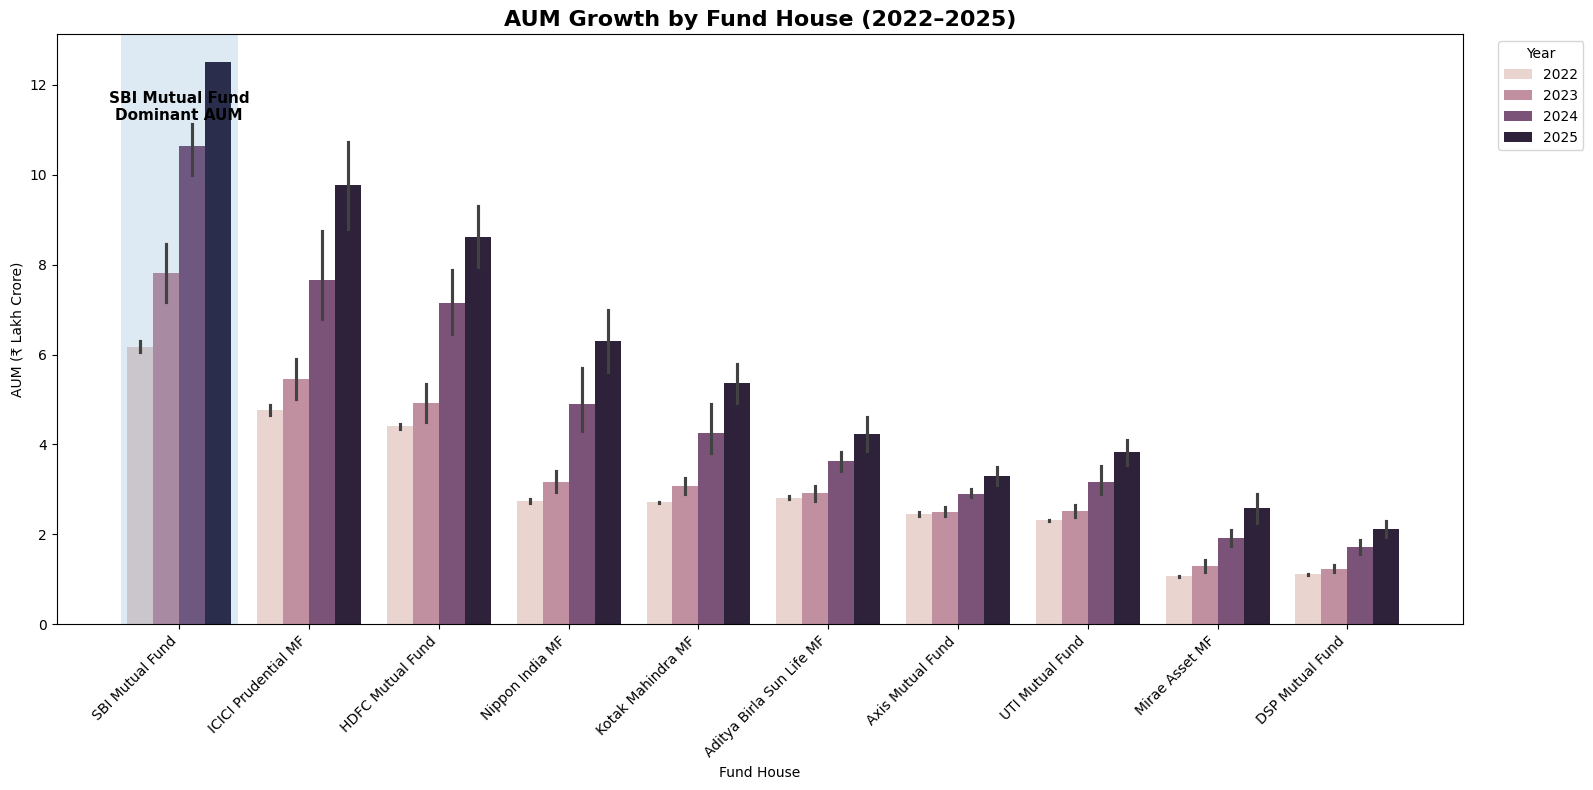

In [ ]:
# ============================================================
# TASK 2 — FINAL AUM CHART WITH SBI HIGHLIGHT
# ============================================================

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=aum_2022_2025,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Highlight SBI
sbi_index = list(
    aum_2022_2025["fund_house"].unique()
).index("SBI Mutual Fund")

plt.axvspan(
    sbi_index - 0.45,
    sbi_index + 0.45,
    alpha=0.15
)

plt.text(
    sbi_index,
    aum_2022_2025["aum_lakh_crore"].max() * 0.95,
    "SBI Mutual Fund\nDominant AUM",
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

# Save PNG for final report
plt.savefig(
    "../reports/AUM_Growth_by_Fund_House.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# TASK 3 — SIP INFLOW TIME-SERIES
# Check actual dataset structure
# ============================================================

print("=" * 70)
print("SIP INFLOW DATA — EDA")
print("=" * 70)

print("\nShape:")
print(sip.shape)

print("\nColumns:")
print(sip.columns.tolist())

print("\nData types:")
print(sip.dtypes)

print("\nFirst 10 rows:")
display(sip.head(10))

SIP INFLOW DATA — EDA

Shape:
(48, 6)

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Data types:
month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

First 10 rows:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN
5,2022-06,12276,5.60,7.50,5.18,NaN
6,2022-07,12140,5.65,9.21,5.25,NaN
7,2022-08,12694,5.71,8.90,5.31,NaN
8,2022-09,12976,5.80,9.40,5.41,NaN
9,2022-10,13040,5.93,9.52,5.55,NaN


In [ ]:
# ============================================================
# TASK 3 — SIP INFLOW TIME-SERIES
# Prepare monthly SIP data
# ============================================================

# Convert month into proper datetime format
sip["month"] = pd.to_datetime(sip["month"])

# Convert SIP inflow to numeric
sip["sip_inflow_crore"] = pd.to_numeric(
    sip["sip_inflow_crore"],
    errors="coerce"
)

# Sort chronologically
sip = sip.sort_values("month").reset_index(drop=True)

print("=" * 70)
print("SIP DATA PREPARED")
print("=" * 70)

print("\nDate range:")
print(sip["month"].min(), "to", sip["month"].max())

print("\nNumber of months:")
print(sip["month"].nunique())

print("\nMissing SIP inflows:")
print(sip["sip_inflow_crore"].isnull().sum())

print("\nHighest SIP inflow:")
display(
    sip.loc[
        sip["sip_inflow_crore"].idxmax()
    ]
)

SIP DATA PREPARED

Date range:
2022-01-01 00:00:00 to 2025-12-01 00:00:00

Number of months:
48

Missing SIP inflows:
0

Highest SIP inflow:


month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [ ]:
# ============================================================
# TASK 3 — MONTHLY SIP INFLOW TIME-SERIES
# Plotly visualization
# ============================================================

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows — January 2022 to December 2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()

In [ ]:
# ============================================================
# TASK 3 — HIGHLIGHT SIP INFLOW ALL-TIME HIGH
# ============================================================

# Find the highest SIP inflow
peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

peak_month = peak_row["month"]
peak_value = peak_row["sip_inflow_crore"]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows — 2022–2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Highlight the peak point
fig.add_trace(
    go.Scatter(
        x=[peak_month],
        y=[peak_value],
        mode="markers+text",
        marker=dict(size=14),
        text=[f"All-Time High: ₹{peak_value:,.0f} Cr"],
        textposition="top center",
        name="All-Time High"
    )
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()

In [41]:
fig.write_image(
    "../reports/SIP_Inflow_Time_Series.png",
    width=1400,
    height=700,
    scale=2
)

print("SIP inflow chart saved successfully!")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [42]:
%pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys

print("Python being used by notebook:")
print(sys.executable)

%pip show kaleido

Python being used by notebook:
c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
Name: kaleido
Version: 1.4.0
Summary: Plotly graph export library
Home-page: https://github.com/plotly/kaleido
Author: 
Author-email: Andrew Pikul <ajpikul@gmail.com>, Neyberson Atencio <neyberatencio@gmail.com>
License: The MIT License (MIT)

Copyright (c) Plotly, Inc

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS O

In [6]:
import kaleido
from importlib.metadata import version, PackageNotFoundError

try:
    print("Kaleido version:", version("kaleido"))
except PackageNotFoundError:
    print("Kaleido version: not installed")

Kaleido version: 1.4.0


In [7]:
import plotly.io as pio

print(pio.kaleido.scope)

IndentationError: expected an indented block after 'if' statement on line 17 (1557847922.py, line 19)

In [12]:
# ============================================================
# TASK 3 — RECREATE FINAL SIP FIGURE
# ============================================================

peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

peak_month = peak_row["month"]
peak_value = peak_row["sip_inflow_crore"]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows — 2022–2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

fig.add_trace(
    go.Scatter(
        x=[peak_month],
        y=[peak_value],
        mode="markers+text",
        marker=dict(size=14),
        text=[f"All-Time High: ₹{peak_value:,.0f} Cr"],
        textposition="top center",
        name="All-Time High"
    )
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()

NameError: name 'sip' is not defined

In [13]:
# ============================================================
# RELOAD SIP DATA AFTER KERNEL RESTART
# ============================================================

sip = pd.read_csv(
    "../data/raw/monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(sip["month"])

sip["sip_inflow_crore"] = pd.to_numeric(
    sip["sip_inflow_crore"],
    errors="coerce"
)

sip = sip.sort_values("month").reset_index(drop=True)

print("SIP data loaded successfully!")
print("Date range:", sip["month"].min(), "to", sip["month"].max())
print("Rows:", len(sip))

NameError: name 'pd' is not defined

In [16]:
# ============================================================
# RESTORE NOTEBOOK IMPORTS AFTER KERNEL RESTART
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

print("Libraries restored successfully!")

Libraries restored successfully!


In [17]:
# ============================================================
# RELOAD SIP DATA
# ============================================================

sip = pd.read_csv(
    "../data/raw/monthly_sip_inflows.csv"
)

sip["month"] = pd.to_datetime(sip["month"])

sip["sip_inflow_crore"] = pd.to_numeric(
    sip["sip_inflow_crore"],
    errors="coerce"
)

sip = sip.sort_values("month").reset_index(drop=True)

print("SIP data loaded successfully!")
print("Date range:", sip["month"].min(), "to", sip["month"].max())
print("Rows:", len(sip))

SIP data loaded successfully!
Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Rows: 48


In [18]:
# ============================================================
# TASK 3 — FINAL SIP INFLOW CHART
# ============================================================

peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

peak_month = peak_row["month"]
peak_value = peak_row["sip_inflow_crore"]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows — January 2022 to December 2025",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

fig.add_trace(
    go.Scatter(
        x=[peak_month],
        y=[peak_value],
        mode="markers+text",
        marker=dict(size=14),
        text=[f"All-Time High: ₹{peak_value:,.0f} Cr"],
        textposition="top center",
        name="All-Time High"
    )
)

fig.update_layout(
    template="plotly_white",
    height=600,
    hovermode="x unified"
)

fig.show()

In [19]:
fig.write_image(
    "../reports/SIP_Inflow_Time_Series.png",
    width=1400,
    height=700,
    scale=2
)

print("SUCCESS — SIP chart saved as PNG.")

SUCCESS — SIP chart saved as PNG.


In [20]:
# ============================================================
# TASK 4 — CATEGORY INFLOW HEATMAP
# Load and inspect category inflow data
# ============================================================

category_inflow = pd.read_csv(
    "../data/raw/category_inflows.csv"
)

print("=" * 70)
print("CATEGORY INFLOW DATA — EDA")
print("=" * 70)

print("\nShape:")
print(category_inflow.shape)

print("\nColumns:")
print(category_inflow.columns.tolist())

print("\nData types:")
print(category_inflow.dtypes)

print("\nFirst 10 rows:")
display(category_inflow.head(10))

print("\nMissing values:")
display(category_inflow.isnull().sum())

CATEGORY INFLOW DATA — EDA

Shape:
(144, 3)

Columns:
['month', 'category', 'net_inflow_crore']

Data types:
month                object
category             object
net_inflow_crore    float64
dtype: object

First 10 rows:


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0
5,2024-04,ELSS,466.0
6,2024-04,Value/Contra,1328.0
7,2024-04,Sectoral/Thematic,8052.0
8,2024-04,Liquid,37537.0
9,2024-04,Short Duration,4400.0



Missing values:


month               0
category            0
net_inflow_crore    0
dtype: int64

In [21]:
# ============================================================
# TASK 4 — CATEGORY INFLOW HEATMAP
# Prepare data for Seaborn
# ============================================================

# Convert month to datetime
category_inflow["month"] = pd.to_datetime(
    category_inflow["month"]
)

# Create a month-category matrix
category_pivot = category_inflow.pivot(
    index="month",
    columns="category",
    values="net_inflow_crore"
)

# Sort chronologically
category_pivot = category_pivot.sort_index()

print("Heatmap matrix shape:")
print(category_pivot.shape)

print("\nMonths:")
print(category_pivot.index)

print("\nCategories:")
print(category_pivot.columns.tolist())

display(category_pivot.head())

Heatmap matrix shape:
(12, 12)

Months:
DatetimeIndex(['2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01',
               '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01'],
              dtype='datetime64[ns]', name='month', freq=None)

Categories:
['ELSS', 'Flexi Cap', 'Gilt', 'Hybrid', 'Large & Mid Cap', 'Large Cap', 'Liquid', 'Mid Cap', 'Sectoral/Thematic', 'Short Duration', 'Small Cap', 'Value/Contra']


category,ELSS,Flexi Cap,Gilt,Hybrid,Large & Mid Cap,Large Cap,Liquid,Mid Cap,Sectoral/Thematic,Short Duration,Small Cap,Value/Contra
month,,,,,,,,,,,,
2024-04-01,466.0,4947.0,784.0,2955.0,4214.0,2413.0,37537.0,3897.0,8052.0,4400.0,3533.0,1328.0
2024-05-01,553.0,5529.0,836.0,3487.0,4368.0,2076.0,41872.0,5300.0,8354.0,4833.0,4092.0,1361.0
2024-06-01,472.0,4478.0,864.0,3163.0,4610.0,2519.0,40486.0,5047.0,10030.0,4321.0,3535.0,1386.0
2024-07-01,471.0,4869.0,959.0,3291.0,5023.0,2574.0,34643.0,4548.0,9896.0,4170.0,3582.0,1582.0
2024-08-01,499.0,5562.0,952.0,3684.0,5411.0,1940.0,41952.0,3899.0,8360.0,4658.0,3376.0,1308.0


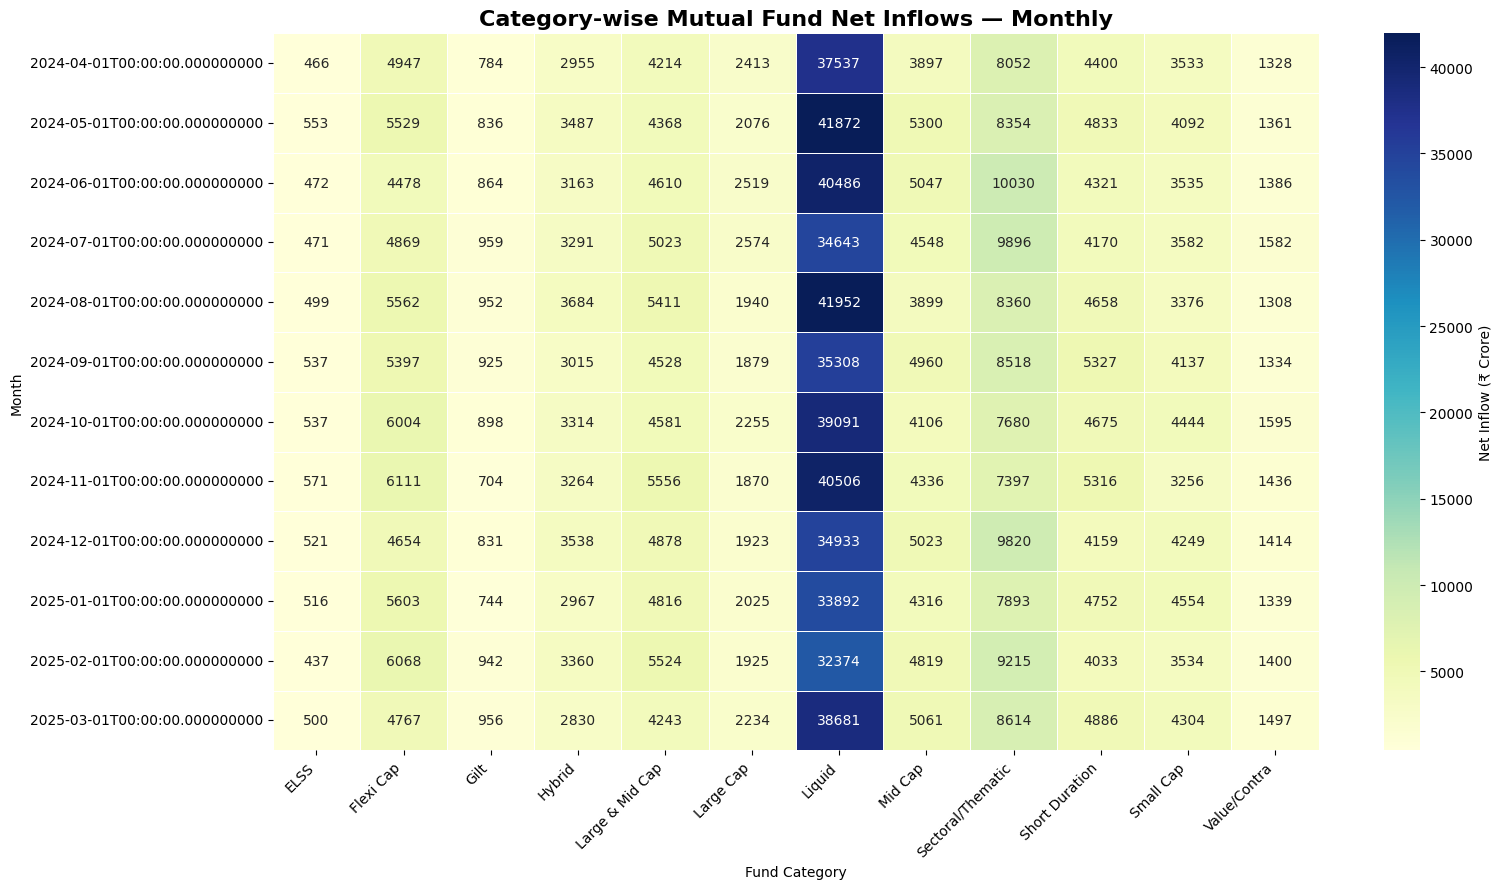

In [22]:
# ============================================================
# TASK 4 — CATEGORY INFLOW HEATMAP
# Seaborn Heatmap
# ============================================================

plt.figure(figsize=(16, 9))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Mutual Fund Net Inflows — Monthly",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund Category")
plt.ylabel("Month")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

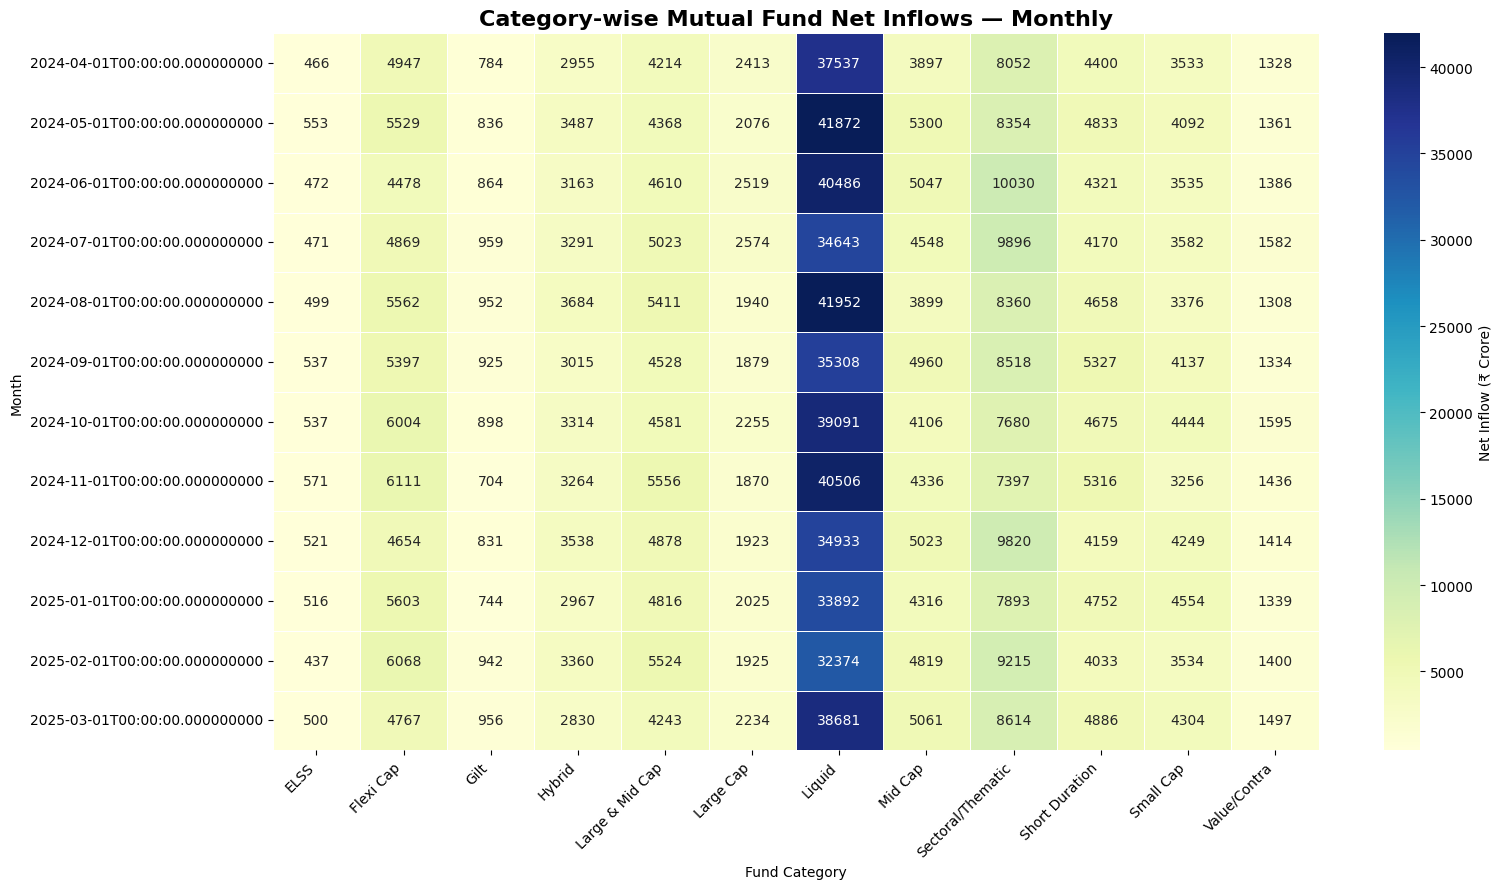

Category inflow heatmap saved successfully!


In [23]:
# ============================================================
# TASK 4 — EXPORT CATEGORY INFLOW HEATMAP
# ============================================================

plt.figure(figsize=(16, 9))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title(
    "Category-wise Mutual Fund Net Inflows — Monthly",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund Category")
plt.ylabel("Month")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/Category_Inflow_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category inflow heatmap saved successfully!")

In [24]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# Load Investor Transactions Data
# ============================================================

investor = pd.read_csv(
    "../data/raw/investor_transactions.csv"
)

print("=" * 70)
print("INVESTOR TRANSACTIONS — EDA")
print("=" * 70)

print("\nShape:")
print(investor.shape)

print("\nColumns:")
print(investor.columns.tolist())

print("\nData Types:")
print(investor.dtypes)

print("\nFirst 10 Rows:")
display(investor.head(10))

print("\nMissing Values:")
display(investor.isnull().sum())

INVESTOR TRANSACTIONS — EDA

Shape:
(32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Data Types:
investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
dtype: object

First 10 Rows:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified
7,INV000616,2024-01-01,100016,SIP,933,Maharashtra,Nashik,B30,36-45,Male,50.4,Mandate,Verified
8,INV003670,2024-01-01,119120,SIP,10672,Punjab,Chandigarh,T30,36-45,Male,38.4,Net Banking,Verified
9,INV002054,2024-01-01,148567,SIP,1111,Telangana,Hyderabad,T30,26-35,Male,17.8,Net Banking,Verified



Missing Values:


investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [25]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [26]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# Inspect Demographic Categories
# ============================================================

print("Age Groups:")
print(investor["age_group"].value_counts())

print("\nGender Distribution:")
print(investor["gender"].value_counts())

print("\nTransaction Types:")
print(investor["transaction_type"].value_counts())

print("\nAmount Statistics:")
display(investor["amount_inr"].describe())

Age Groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender Distribution:
gender
Male      21809
Female    10969
Name: count, dtype: int64

Transaction Types:
transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

Amount Statistics:


count     32778.000000
mean     107437.318628
std      150415.905084
min         400.000000
25%        3153.000000
50%       17782.500000
75%      189324.250000
max      597498.000000
Name: amount_inr, dtype: float64

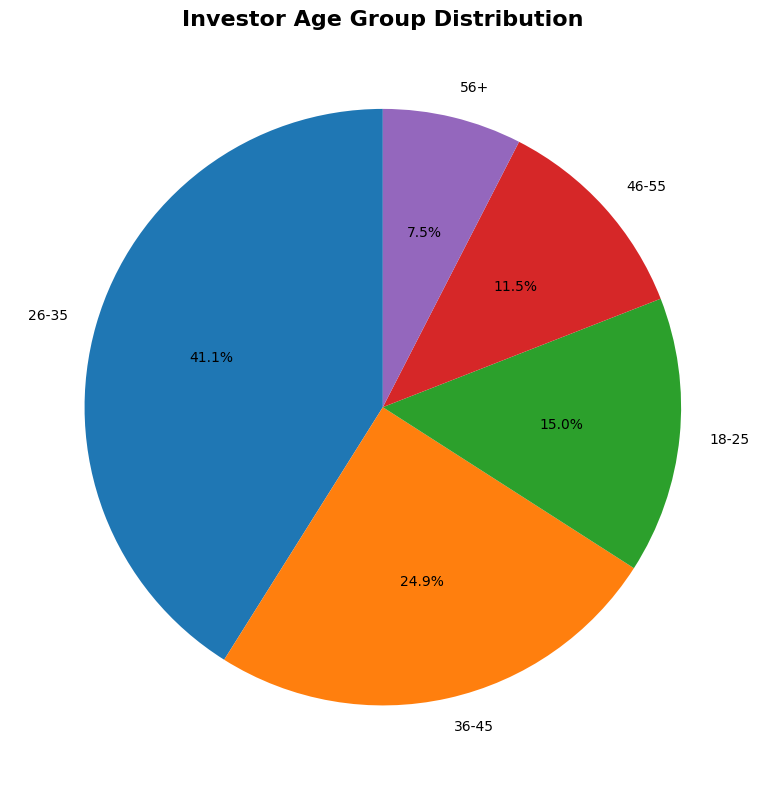

In [27]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# 1. Age Distribution Pie Chart
# ============================================================

age_distribution = investor["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_distribution.values,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Number of SIP transactions: 19716

SIP Amount Statistics:


count    19716.000000
mean     11018.132025
std      14218.202038
min        400.000000
25%       2116.750000
50%       5139.000000
75%      13554.250000
max      59998.000000
Name: amount_inr, dtype: float64

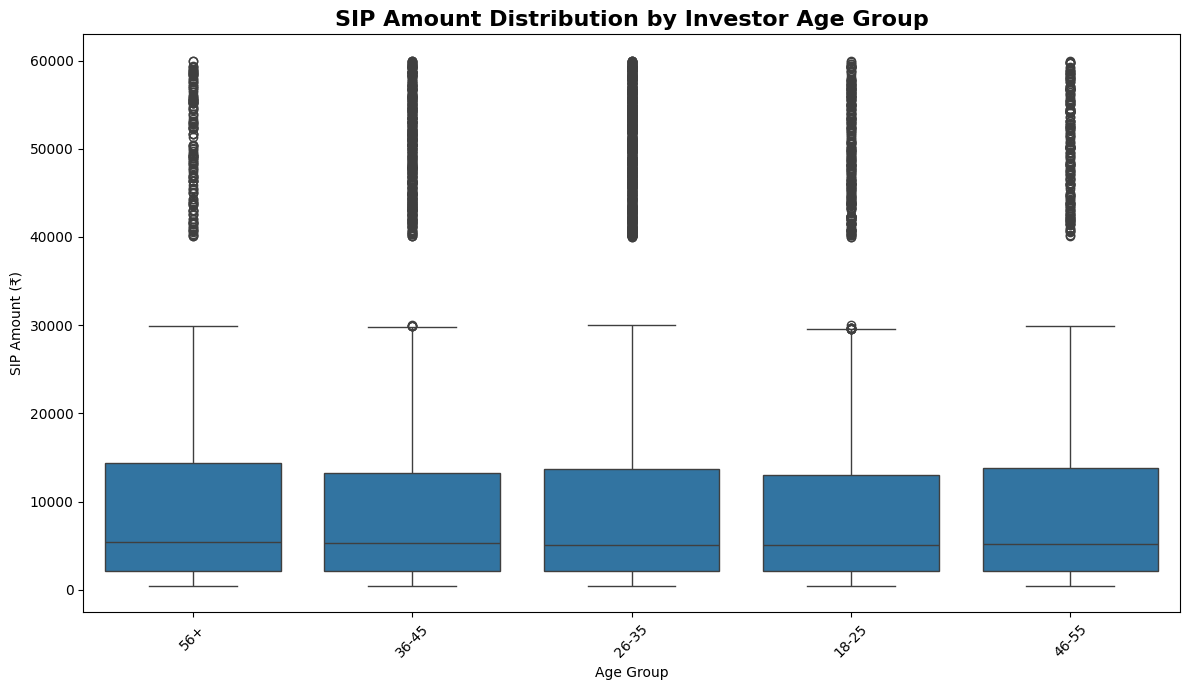

In [28]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# 2. SIP Amount Box Plot by Age Group
# ============================================================

sip_transactions = investor[
    investor["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

print("Number of SIP transactions:", len(sip_transactions))

print("\nSIP Amount Statistics:")
display(sip_transactions["amount_inr"].describe())

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Investor Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

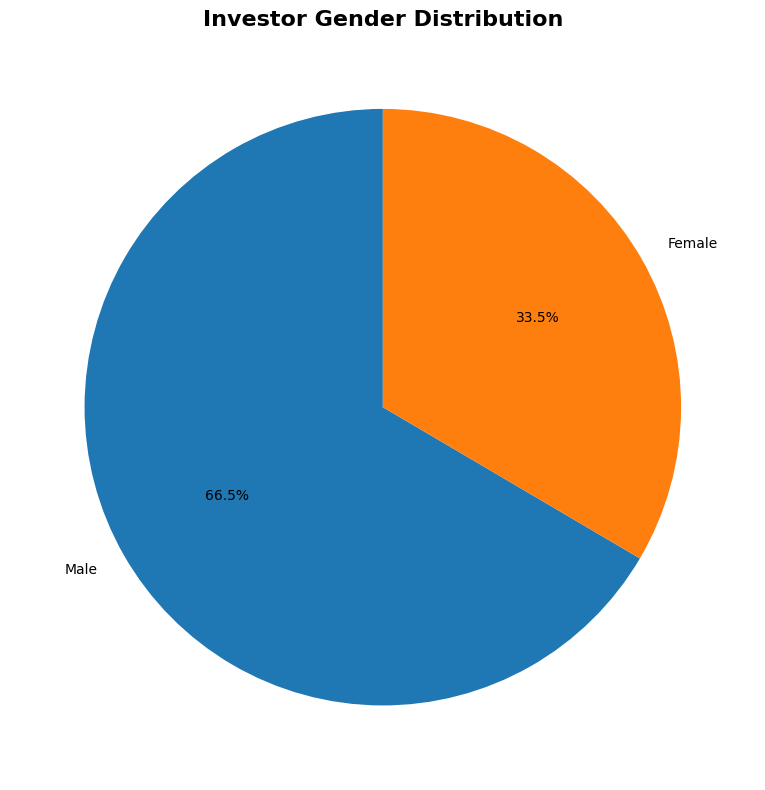

In [29]:
# ============================================================
# TASK 5 — INVESTOR DEMOGRAPHICS
# 3. Gender Split
# ============================================================

gender_distribution = investor["gender"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    gender_distribution.values,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Gender Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

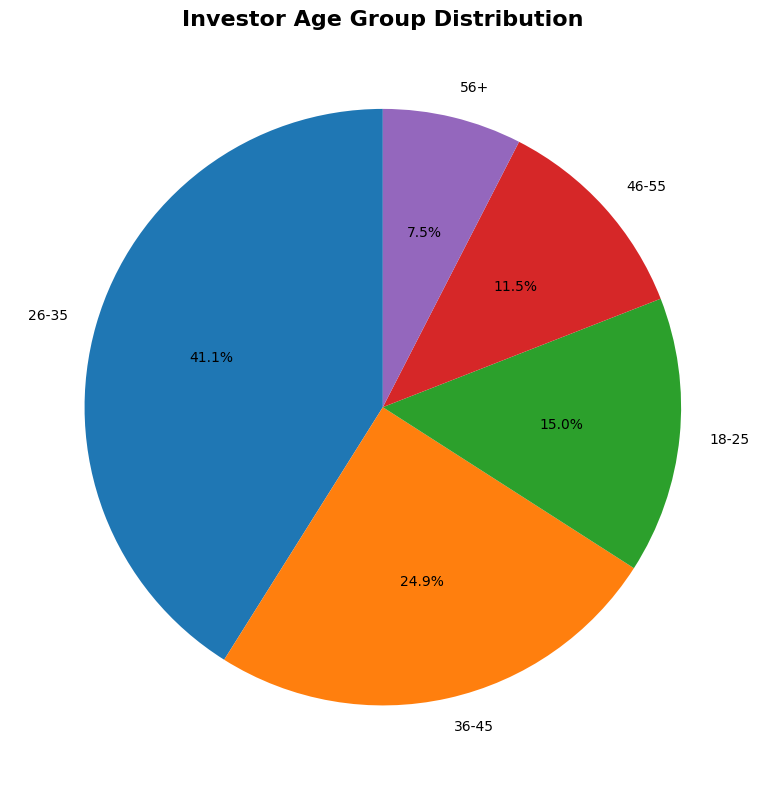

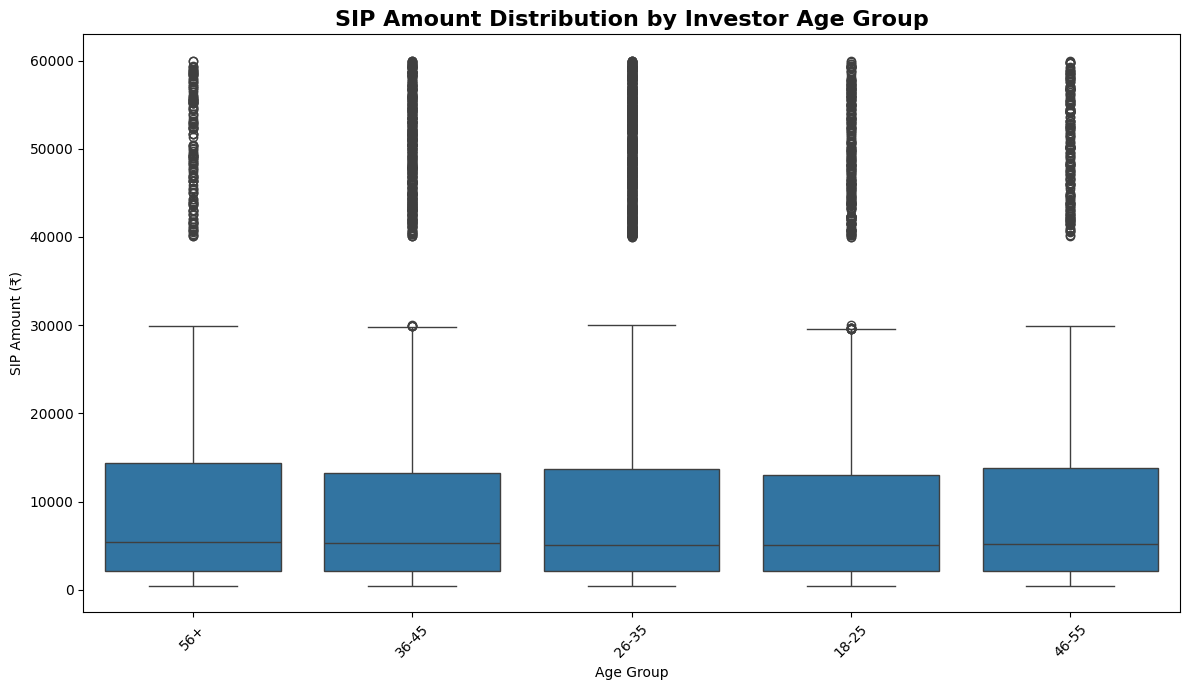

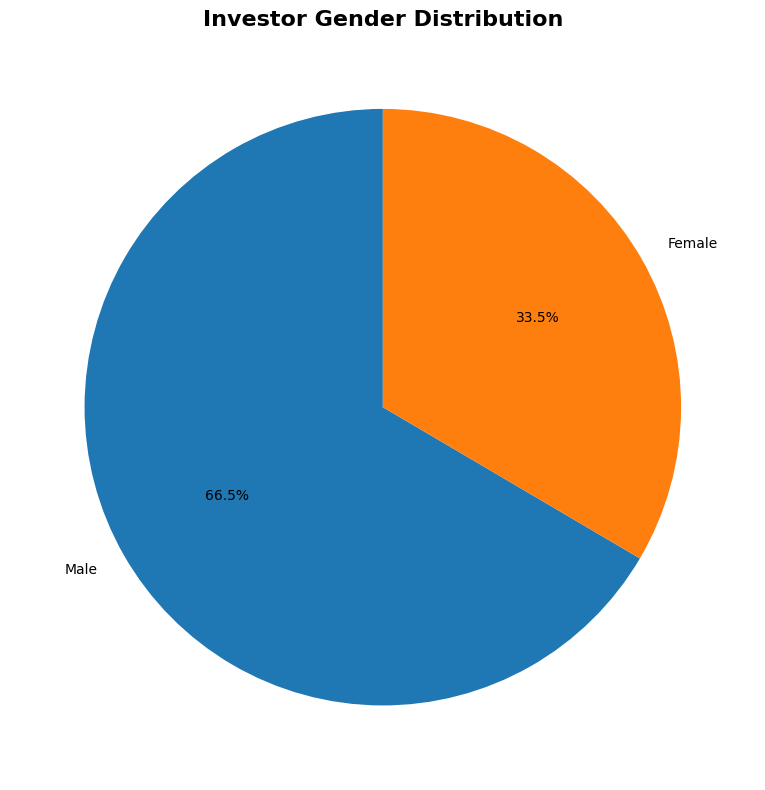

All 3 Task 5 demographic charts exported successfully!


In [30]:
# ============================================================
# TASK 5 — EXPORT DEMOGRAPHIC CHARTS
# ============================================================

# ---------- 1. Age Distribution ----------
plt.figure(figsize=(8, 8))

plt.pie(
    age_distribution.values,
    labels=age_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/Investor_Age_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 2. SIP Amount by Age Group ----------
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Investor Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/SIP_Amount_by_Age_Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 3. Gender Distribution ----------
plt.figure(figsize=(8, 8))

plt.pie(
    gender_distribution.values,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Gender Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/Investor_Gender_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("All 3 Task 5 demographic charts exported successfully!")

In [31]:
# ============================================================
# TASK 6 — GEOGRAPHIC DISTRIBUTION
# Prepare SIP Geographic Data
# ============================================================

# Use only SIP transactions
sip_geo = investor[
    investor["transaction_type"].astype(str).str.upper() == "SIP"
].copy()

# Convert amount to numeric
sip_geo["amount_inr"] = pd.to_numeric(
    sip_geo["amount_inr"],
    errors="coerce"
)

# Remove rows where required geographic information is missing
sip_geo = sip_geo.dropna(
    subset=["state", "amount_inr", "city_tier"]
)

print("=" * 70)
print("GEOGRAPHIC SIP DATA")
print("=" * 70)

print("\nNumber of SIP records:", len(sip_geo))

print("\nNumber of states:", sip_geo["state"].nunique())

print("\nStates:")
print(sip_geo["state"].unique())

print("\nCity Tier Distribution:")
print(sip_geo["city_tier"].value_counts())

GEOGRAPHIC SIP DATA

Number of SIP records: 19716

Number of states: 12

States:
['Telangana' 'Haryana' 'Maharashtra' 'Madhya Pradesh' 'Punjab' 'Gujarat'
 'Rajasthan' 'Karnataka' 'West Bengal' 'Tamil Nadu' 'Delhi'
 'Uttar Pradesh']

City Tier Distribution:
city_tier
T30    13123
B30     6593
Name: count, dtype: int64


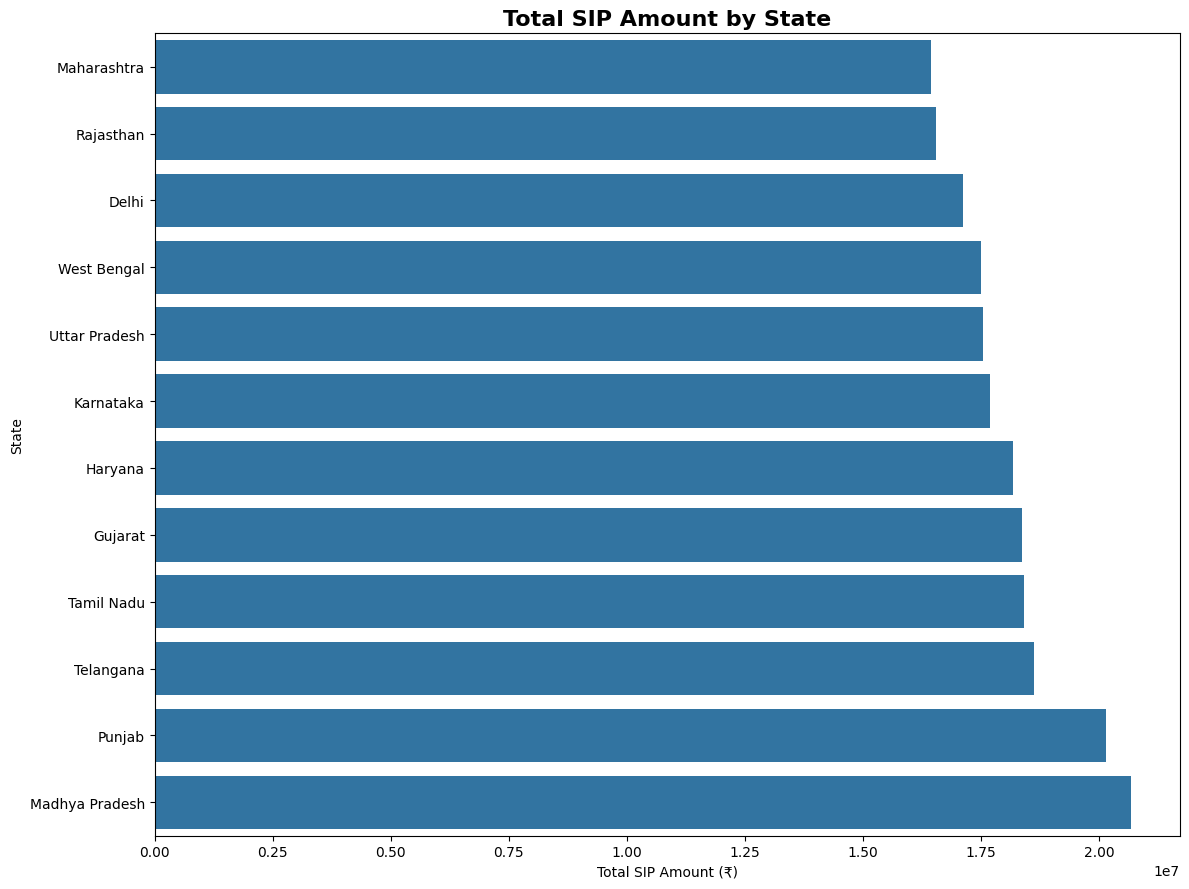

In [32]:
# ============================================================
# TASK 6 — GEOGRAPHIC DISTRIBUTION
# 1. Horizontal SIP Amount by State
# ============================================================

state_sip = (
    sip_geo
    .groupby("state", as_index=False)["amount_inr"]
    .sum()
    .sort_values("amount_inr", ascending=True)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title(
    "Total SIP Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()


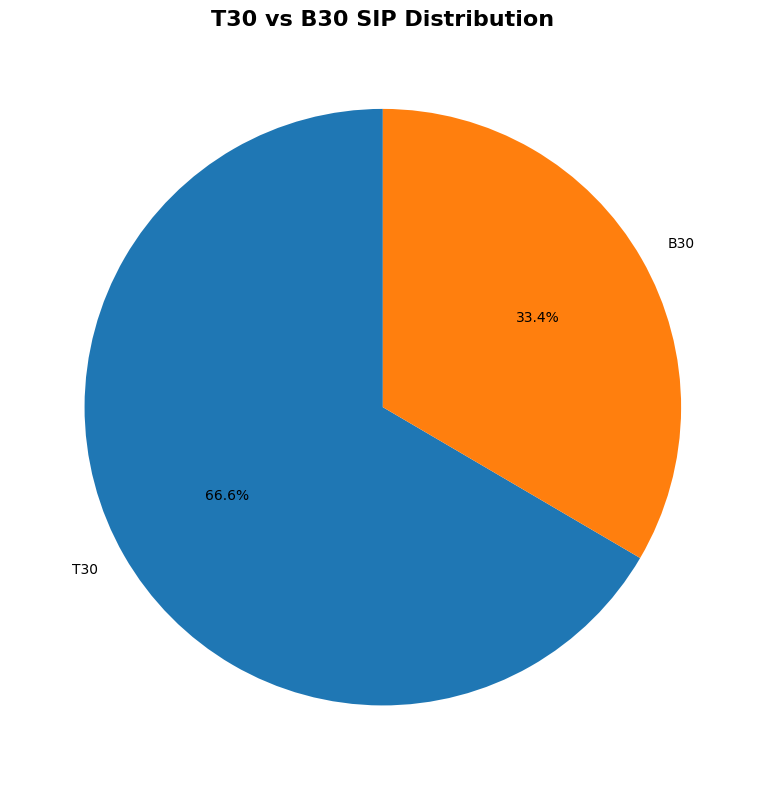

In [33]:
# ============================================================
# TASK 6 — GEOGRAPHIC DISTRIBUTION
# 2. T30 vs B30 City Tier Distribution
# ============================================================

city_tier_distribution = sip_geo["city_tier"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    city_tier_distribution.values,
    labels=city_tier_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 SIP Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

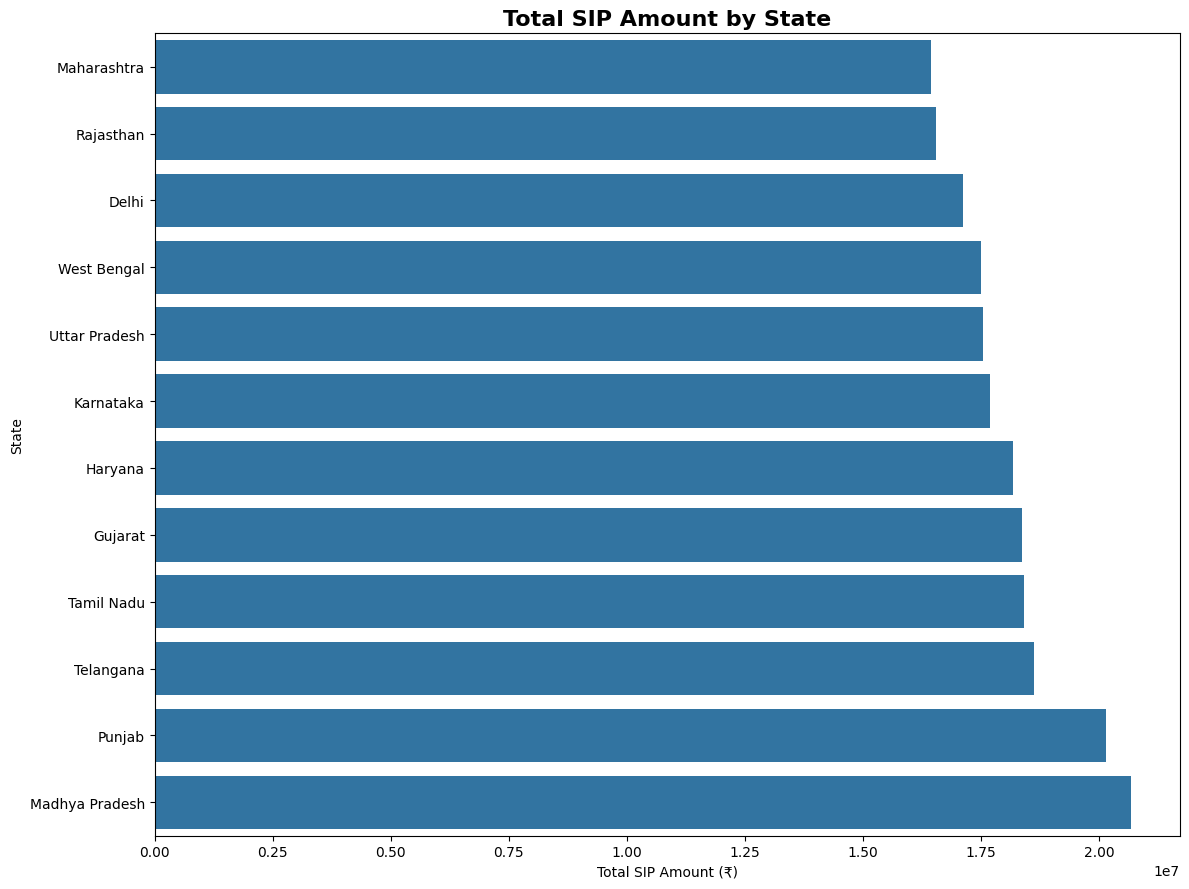

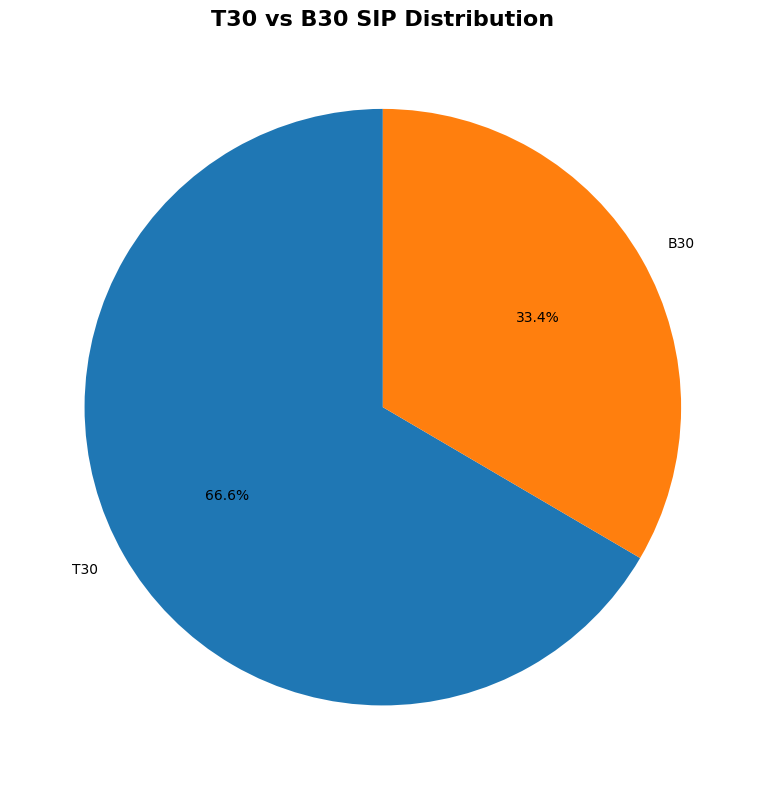

Task 6 charts exported successfully!


In [34]:
# ============================================================
# TASK 6 — EXPORT GEOGRAPHIC DISTRIBUTION CHARTS
# ============================================================

# ---------- 1. SIP Amount by State ----------
plt.figure(figsize=(12, 9))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title(
    "Total SIP Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/SIP_Amount_by_State.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------- 2. T30 vs B30 ----------
plt.figure(figsize=(8, 8))

plt.pie(
    city_tier_distribution.values,
    labels=city_tier_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 SIP Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../reports/T30_vs_B30_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 6 charts exported successfully!")

In [36]:
# ============================================================
# TASK 7 — FOLIO COUNT GROWTH
# Load Folio Count Data
# ============================================================

folio = pd.read_csv(
    "../data/raw/industry_folio_count.csv"
)

print("=" * 70)
print("FOLIO COUNT DATA — EDA")
print("=" * 70)

print("\nShape:")
print(folio.shape)

print("\nColumns:")
print(folio.columns.tolist())

print("\nData Types:")
print(folio.dtypes)

print("\nFirst 10 Rows:")
display(folio.head(10))

print("\nMissing Values:")
display(folio.isnull().sum())

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/industry_folio_count.csv'

In [37]:
import os

print("Files available in data/raw:")
for file in os.listdir("../data/raw"):
    print(file)

Files available in data/raw:
api
aum_by_fund_house.csv
axis_bluechip_nav.csv
benchmark_indices.csv
category_inflows.csv
fund_master.csv
hdfc_top_100_direct_nav.csv
icici_bluechip_nav.csv
investor_transactions.csv
kotak_bluechip_nav.csv
monthly_sip_inflows.csv
nav_history.csv
ndustry_folio_count.csv
nippon_large_cap_nav.csv
portfolio_holdings.csv
sbi_bluechip_nav.csv
scheme_performance.csv


In [38]:
# ============================================================
# TASK 7 — FOLIO COUNT GROWTH
# Load Folio Count Data
# ============================================================

folio = pd.read_csv(
    "../data/raw/ndustry_folio_count.csv"
)

print("=" * 70)
print("FOLIO COUNT DATA — EDA")
print("=" * 70)

print("\nShape:")
print(folio.shape)

print("\nColumns:")
print(folio.columns.tolist())

print("\nData Types:")
print(folio.dtypes)

print("\nFirst 10 Rows:")
display(folio.head(10))

print("\nMissing Values:")
display(folio.isnull().sum())

FOLIO COUNT DATA — EDA

Shape:
(21, 6)

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Data Types:
month                   object
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_folios_crore    float64
others_folios_crore    float64
dtype: object

First 10 Rows:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48
5,2023-04,15.54,10.88,2.18,0.93,1.55
6,2023-07,16.28,11.40,2.28,0.98,1.63
7,2023-10,16.72,11.70,2.34,1.00,1.67
8,2024-01,17.78,12.45,2.49,1.07,1.78
9,2024-04,18.85,13.20,2.64,1.13,1.89



Missing Values:


month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

In [39]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [40]:
# ============================================================
# TASK 7 — FOLIO COUNT GROWTH
# Prepare Monthly Folio Data
# ============================================================

folio["month"] = pd.to_datetime(folio["month"])

folio["total_folios_crore"] = pd.to_numeric(
    folio["total_folios_crore"],
    errors="coerce"
)

folio = folio.sort_values("month").reset_index(drop=True)

# Keep the required period
folio_2022_2025 = folio[
    (folio["month"] >= "2022-01-01") &
    (folio["month"] <= "2025-12-31")
].copy()

print("Date range:")
print("Start:", folio_2022_2025["month"].min())
print("End:", folio_2022_2025["month"].max())

print("\nNumber of months:", len(folio_2022_2025))

print("\nStarting folio count:")
print(folio_2022_2025.iloc[0]["total_folios_crore"], "Cr")

print("\nEnding folio count:")
print(folio_2022_2025.iloc[-1]["total_folios_crore"], "Cr")

display(folio_2022_2025.head())
display(folio_2022_2025.tail())

Date range:
Start: 2022-01-01 00:00:00
End: 2025-12-01 00:00:00

Number of months: 21

Starting folio count:
13.26 Cr

Ending folio count:
26.12 Cr


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
16,2025-07-01,24.57,17.20,3.44,1.47,2.46
17,2025-08-01,24.89,17.42,3.48,1.49,2.49
18,2025-09-01,25.19,17.63,3.53,1.51,2.52
19,2025-10-01,25.60,17.92,3.58,1.54,2.56
20,2025-12-01,26.12,18.28,3.66,1.57,2.61


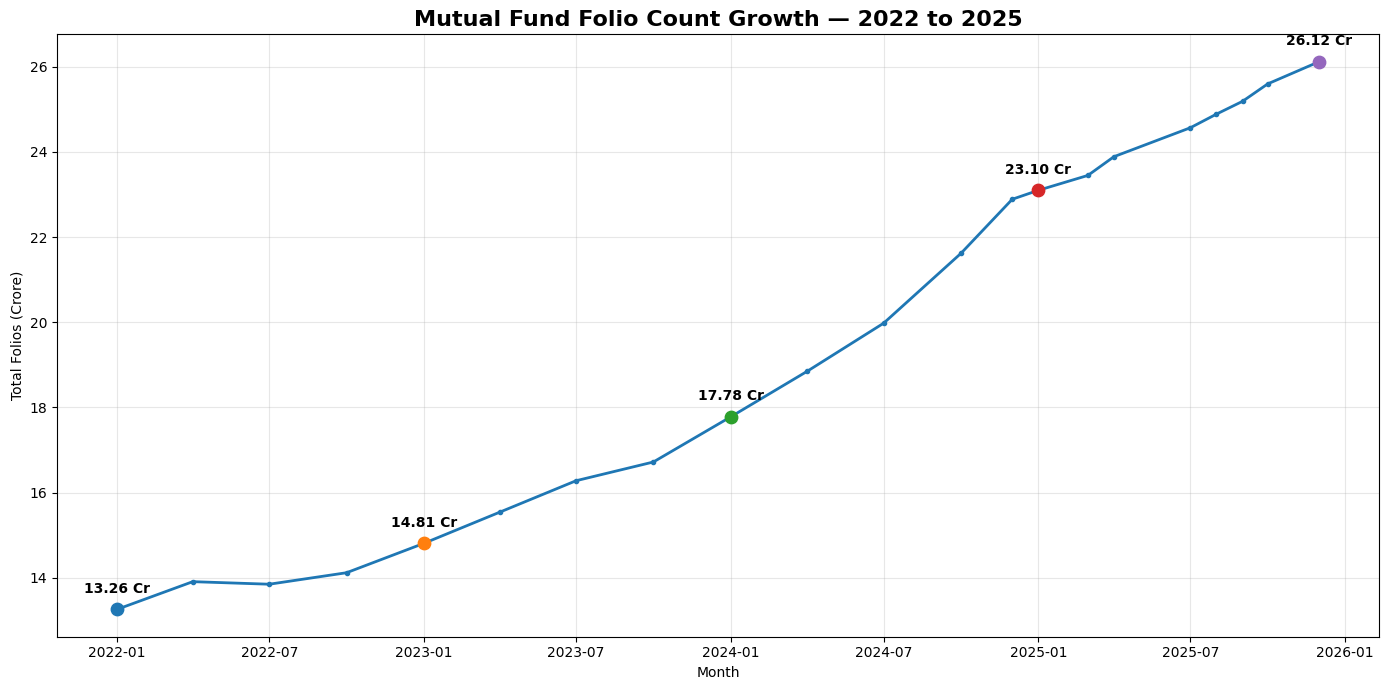

In [41]:
# ============================================================
# TASK 7 — FOLIO COUNT GROWTH
# January 2022 to December 2025
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    folio_2022_2025["month"],
    folio_2022_2025["total_folios_crore"],
    marker="o",
    markersize=3,
    linewidth=2
)

# Mark important milestones
milestone_dates = [
    "2022-01-01",
    "2023-01-01",
    "2024-01-01",
    "2025-01-01",
    "2025-12-01"
]

for date in milestone_dates:
    date = pd.Timestamp(date)

    row = folio_2022_2025[
        folio_2022_2025["month"] == date
    ]

    if not row.empty:
        value = row["total_folios_crore"].iloc[0]

        plt.scatter(
            date,
            value,
            s=80,
            zorder=5
        )

        plt.annotate(
            f"{value:.2f} Cr",
            xy=(date, value),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Mutual Fund Folio Count Growth — 2022 to 2025",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

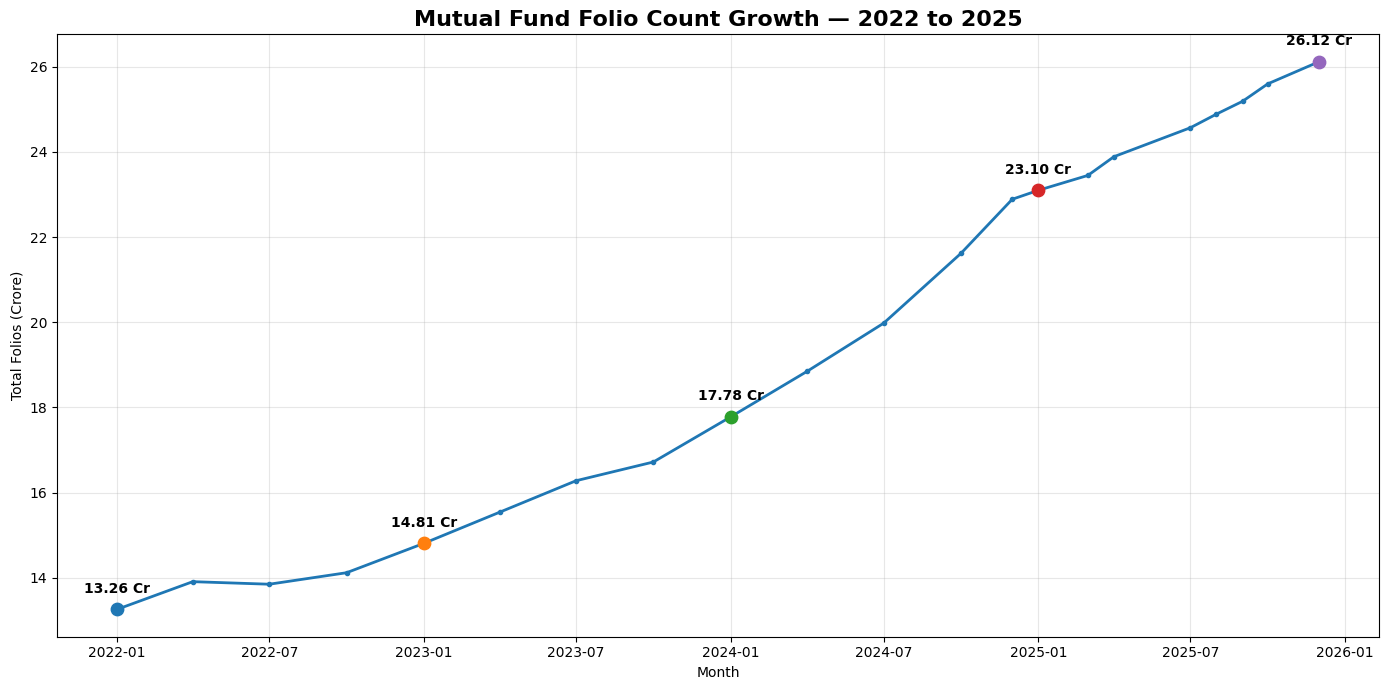

Folio count growth chart exported successfully!


In [42]:
# ============================================================
# TASK 7 — EXPORT FOLIO COUNT GROWTH CHART
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    folio_2022_2025["month"],
    folio_2022_2025["total_folios_crore"],
    marker="o",
    markersize=3,
    linewidth=2
)

# Mark important milestones
milestone_dates = [
    "2022-01-01",
    "2023-01-01",
    "2024-01-01",
    "2025-01-01",
    "2025-12-01"
]

for date in milestone_dates:
    date = pd.Timestamp(date)

    row = folio_2022_2025[
        folio_2022_2025["month"] == date
    ]

    if not row.empty:
        value = row["total_folios_crore"].iloc[0]

        plt.scatter(
            date,
            value,
            s=80,
            zorder=5
        )

        plt.annotate(
            f"{value:.2f} Cr",
            xy=(date, value),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.title(
    "Mutual Fund Folio Count Growth — 2022 to 2025",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/Folio_Count_Growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Folio count growth chart exported successfully!")

In [44]:
# ============================================================
# TASK 8 — NAV RETURN CORRELATION MATRIX
# Load NAV History and Calculate Daily Returns
# ============================================================

nav_history = pd.read_csv(
    "../data/raw/nav_history.csv"
)

nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history["nav"] = pd.to_numeric(
    nav_history["nav"],
    errors="coerce"
)

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Calculate daily returns
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print("=" * 70)
print("NAV RETURN CORRELATION — PREPARATION")
print("=" * 70)

print("\nNumber of schemes:")
print(nav_history["amfi_code"].nunique())

print("\nDate range:")
print(nav_history["date"].min(), "to", nav_history["date"].max())

print("\nFirst 10 records:")
display(
    nav_history[
        ["date", "amfi_code", "nav", "daily_return"]
    ].head(10)
)

NAV RETURN CORRELATION — PREPARATION

Number of schemes:
40

Date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

First 10 records:


,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-10,100016,510.7136,-0.008639
6,2022-01-11,100016,513.5542,0.005562
7,2022-01-12,100016,512.3195,-0.002404
8,2022-01-13,100016,510.2445,-0.004050
9,2022-01-14,100016,514.3636,0.008073


In [45]:
# ============================================================
# TASK 8 — NAV RETURN CORRELATION MATRIX
# Select 10 Funds
# ============================================================

selected_funds = (
    nav_history["amfi_code"]
    .dropna()
    .drop_duplicates()
    .head(10)
    .tolist()
)

print("Selected 10 AMFI Codes:")
print(selected_funds)

print("\nNumber of selected funds:")
print(len(selected_funds))

Selected 10 AMFI Codes:
[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632]

Number of selected funds:
10


In [46]:
# ============================================================
# TASK 8 — NAV RETURN CORRELATION MATRIX
# Create Correlation Matrix
# ============================================================

selected_returns = nav_history[
    nav_history["amfi_code"].isin(selected_funds)
].copy()

# Convert data into:
# Rows    -> Dates
# Columns -> Funds
# Values  -> Daily Returns

return_matrix = selected_returns.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Calculate pairwise correlation
correlation_matrix = return_matrix.corr()

print("=" * 70)
print("10-FUND DAILY RETURN CORRELATION MATRIX")
print("=" * 70)

print("\nMatrix shape:")
print(correlation_matrix.shape)

display(correlation_matrix)

10-FUND DAILY RETURN CORRELATION MATRIX

Matrix shape:
(10, 10)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


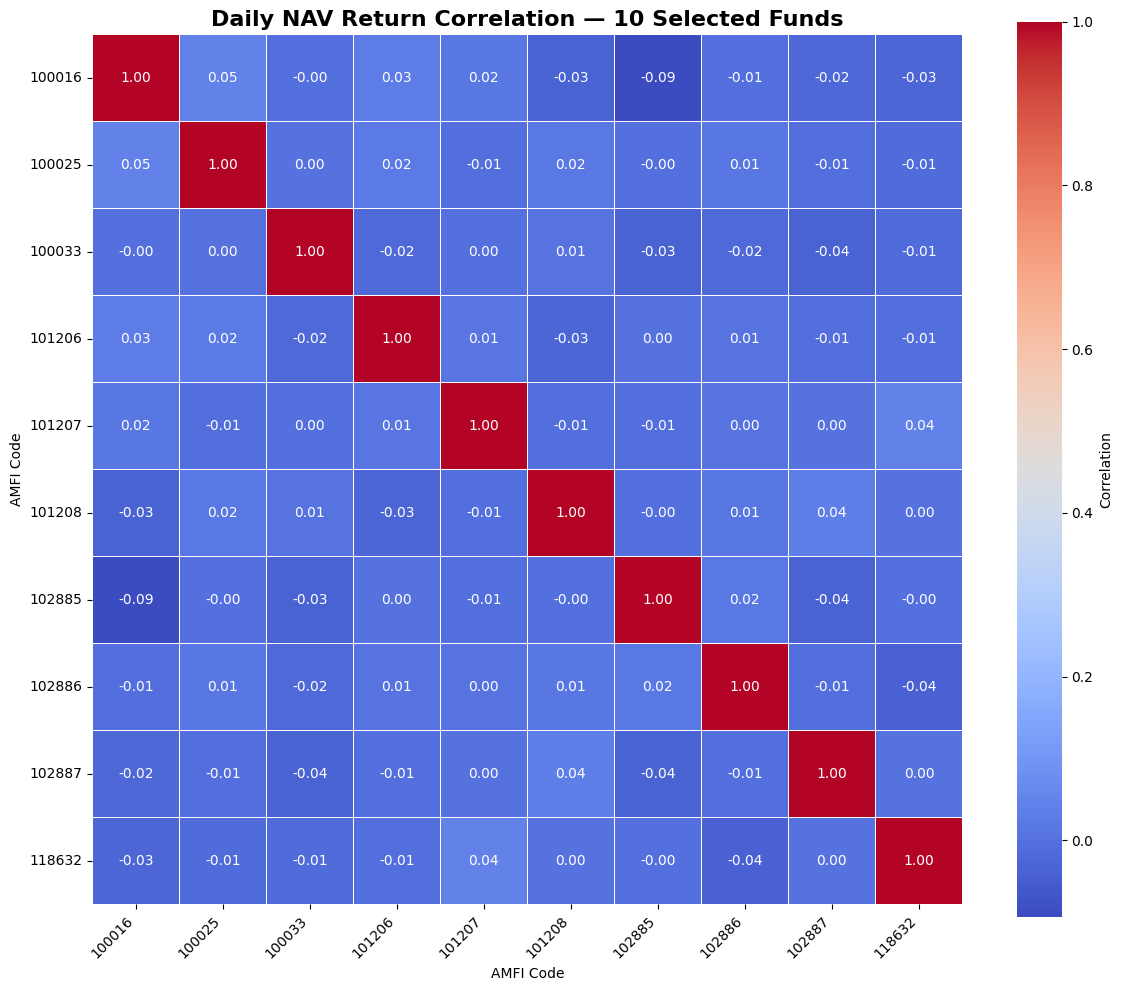

In [47]:
# ============================================================
# TASK 8 — NAV RETURN CORRELATION MATRIX
# Seaborn Heatmap
# ============================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Daily NAV Return Correlation — 10 Selected Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

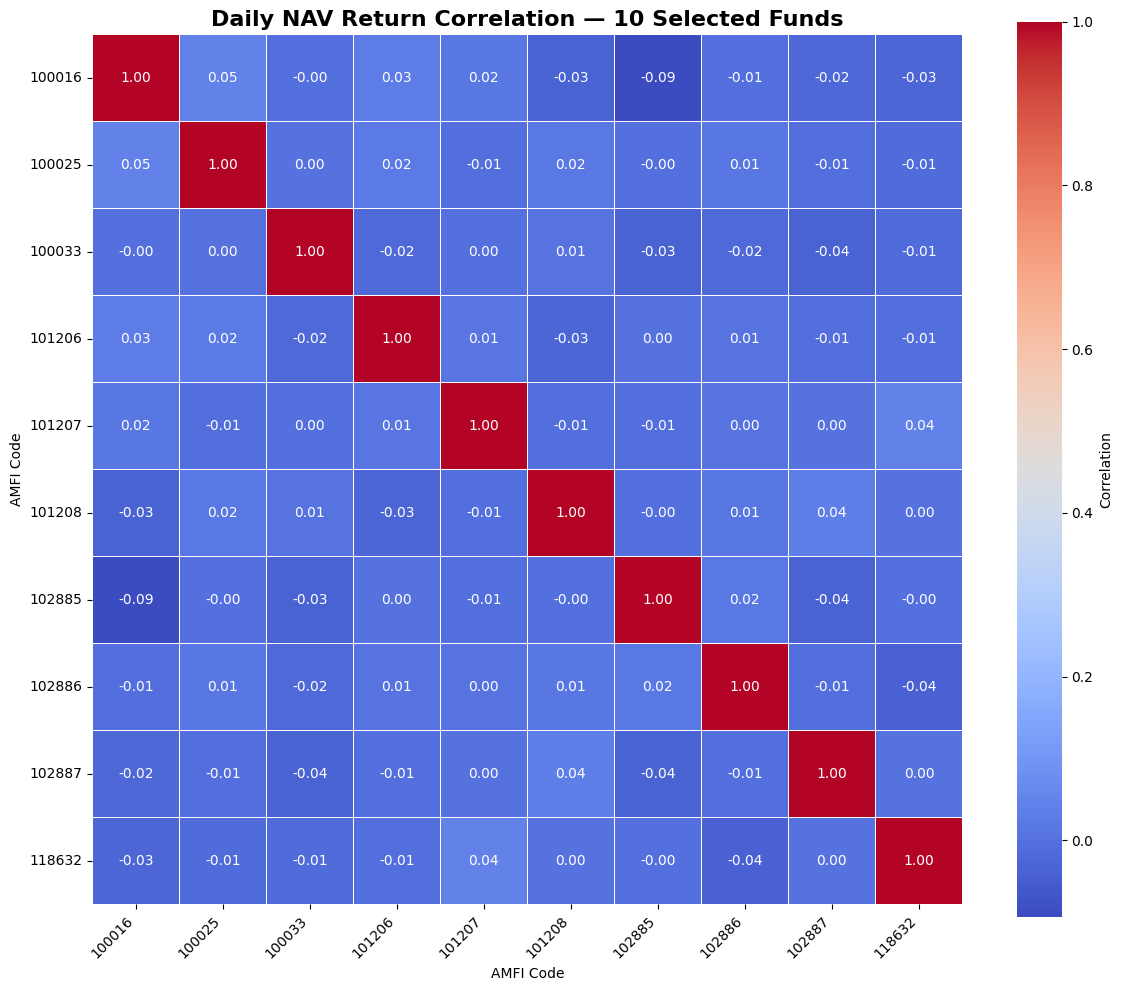

NAV return correlation heatmap exported successfully!


In [48]:
# ============================================================
# TASK 8 — EXPORT NAV RETURN CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Daily NAV Return Correlation — 10 Selected Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("AMFI Code")
plt.ylabel("AMFI Code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/NAV_Return_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("NAV return correlation heatmap exported successfully!")

In [49]:
# ============================================================
# TASK 9 — SECTOR ALLOCATION DONUT
# Load Portfolio Holdings Data
# ============================================================

portfolio = pd.read_csv(
    "../data/raw/portfolio_holdings.csv"
)

print("=" * 70)
print("PORTFOLIO HOLDINGS — SECTOR ANALYSIS")
print("=" * 70)

print("\nShape:")
print(portfolio.shape)

print("\nColumns:")
print(portfolio.columns.tolist())

print("\nData Types:")
print(portfolio.dtypes)

print("\nFirst 10 Rows:")
display(portfolio.head(10))

print("\nMissing Values:")
display(portfolio.isnull().sum())

PORTFOLIO HOLDINGS — SECTOR ANALYSIS

Shape:
(322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Data Types:
amfi_code              int64
stock_symbol          object
stock_name            object
sector                object
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date        object
dtype: object

First 10 Rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31
5,119551,NTPC,NTPC Ltd,Utilities,7.48,897.70,2913.66,2025-12-31
6,119551,DIVISLAB,Divi's Laboratories,Pharma,3.21,286.44,3964.01,2025-12-31
7,119551,BHARTIARTL,Bharti Airtel Ltd,Telecom,13.94,452.19,5013.45,2025-12-31
8,119551,HCLTECH,HCL Technologies Ltd,IT,18.22,177.35,6024.13,2025-12-31
9,119551,MARUTI,Maruti Suzuki India Ltd,Automobile,7.20,1982.33,5461.85,2025-12-31



Missing Values:


amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [50]:
# ============================================================
# TASK 9 — SECTOR ALLOCATION DONUT
# Load Portfolio Holdings Data
# ============================================================

portfolio = pd.read_csv(
    "../data/raw/portfolio_holdings.csv"
)

print("=" * 70)
print("PORTFOLIO HOLDINGS — SECTOR ANALYSIS")
print("=" * 70)

print("\nShape:")
print(portfolio.shape)

print("\nColumns:")
print(portfolio.columns.tolist())

print("\nData Types:")
print(portfolio.dtypes)

print("\nFirst 10 Rows:")
display(portfolio.head(10))

print("\nMissing Values:")
display(portfolio.isnull().sum())

PORTFOLIO HOLDINGS — SECTOR ANALYSIS

Shape:
(322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Data Types:
amfi_code              int64
stock_symbol          object
stock_name            object
sector                object
weight_pct           float64
market_value_cr      float64
current_price_inr    float64
portfolio_date        object
dtype: object

First 10 Rows:


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31
5,119551,NTPC,NTPC Ltd,Utilities,7.48,897.70,2913.66,2025-12-31
6,119551,DIVISLAB,Divi's Laboratories,Pharma,3.21,286.44,3964.01,2025-12-31
7,119551,BHARTIARTL,Bharti Airtel Ltd,Telecom,13.94,452.19,5013.45,2025-12-31
8,119551,HCLTECH,HCL Technologies Ltd,IT,18.22,177.35,6024.13,2025-12-31
9,119551,MARUTI,Maruti Suzuki India Ltd,Automobile,7.20,1982.33,5461.85,2025-12-31



Missing Values:


amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [51]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [52]:
# ============================================================
# TASK 9 — SECTOR ALLOCATION DONUT
# Identify Equity Funds
# ============================================================

# Load fund master data
fund_master = pd.read_csv(
    "../data/raw/fund_master.csv"
)

print("Fund Master Categories:")

display(
    fund_master[
        ["amfi_code", "scheme_name", "category", "sub_category"]
    ].head(10)
)

print("\nUnique Categories:")
print(fund_master["category"].unique())

print("\nUnique Sub-Categories:")
print(fund_master["sub_category"].unique())

Fund Master Categories:


,amfi_code,scheme_name,category,sub_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,Equity,Large Cap
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,Mid Cap
9,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration



Unique Categories:
['Equity' 'Debt']

Unique Sub-Categories:
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']


In [53]:
print(fund_master["category"].unique())
print(fund_master["sub_category"].unique())

['Equity' 'Debt']
['Large Cap' 'Small Cap' 'Gilt' 'Mid Cap' 'Short Duration' 'Value'
 'Liquid' 'Index/ETF' 'Flexi Cap' 'Index' 'Large & Mid Cap' 'ELSS']


In [54]:
# Get AMFI codes of all equity funds
equity_funds = fund_master[
    fund_master["category"].str.contains("Equity", case=False, na=False)
]["amfi_code"].unique()

print("Number of equity funds:", len(equity_funds))
print("Equity AMFI codes:", equity_funds)

Number of equity funds: 34
Equity AMFI codes: [119551 119552 119598 119599 100016 125497 100033 125498 120503 120504
 120505 120506 118632 118633 118634 118635 120841 120842 120843 119092
 119093 119094 119095 101206 101207 102885 102886 102887 148567 148568
 148569 149322 149323 149324]


In [55]:
# Load portfolio holdings
portfolio = pd.read_csv("../data/raw/portfolio_holdings.csv")

# Keep only holdings belonging to equity funds
equity_portfolio = portfolio[
    portfolio["amfi_code"].isin(equity_funds)
].copy()

print("Equity portfolio shape:", equity_portfolio.shape)
print("Number of equity funds found:",
      equity_portfolio["amfi_code"].nunique())

display(equity_portfolio.head())

Equity portfolio shape: (322, 8)
Number of equity funds found: 34


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [56]:
# Aggregate portfolio weight by sector
sector_allocation = (
    equity_portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Normalize to 100% so the donut represents the overall sector allocation
sector_allocation = (
    sector_allocation / sector_allocation.sum() * 100
)

print("Sector allocation:")
display(sector_allocation)

Sector allocation:


sector
Banking           19.184174
IT                13.396216
Pharma            11.983859
Automobile         9.519146
Utilities          7.810023
FMCG               6.738549
Infrastructure     5.651781
Diversified        4.977368
Telecom            4.282954
Consumer Goods     3.753246
NBFC               3.502657
Energy             3.467951
Cement             3.089127
Paints             2.642949
Name: weight_pct, dtype: float64

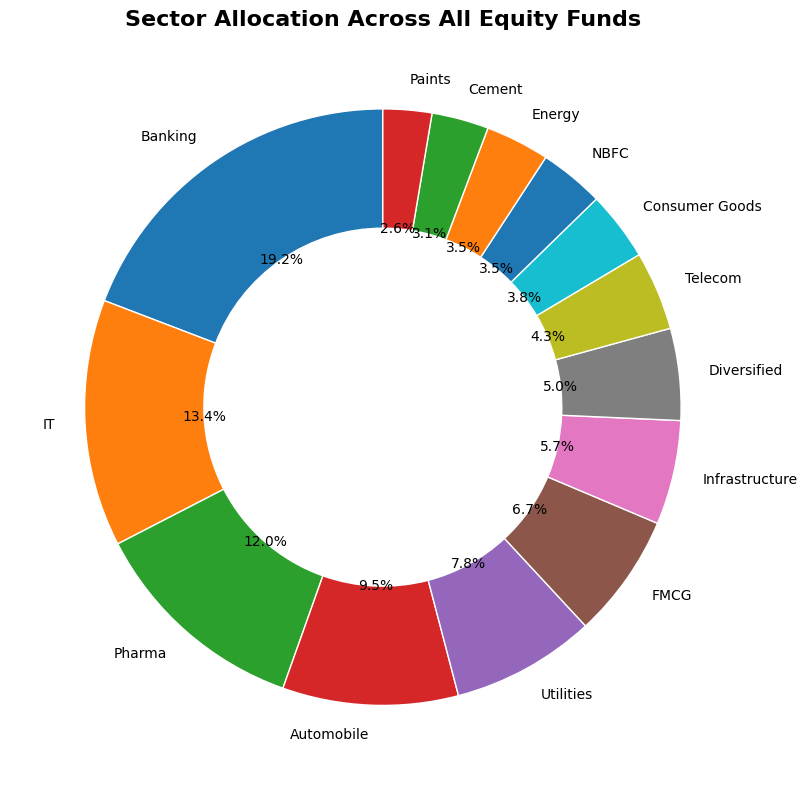

In [57]:
# Sector Allocation Donut Chart

fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(
    sector_allocation.values,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

ax.set_title(
    "Sector Allocation Across All Equity Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# Save chart for the final report
plt.savefig(
    "../reports/Sector_Allocation_Donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key EDA Findings

### Finding 1 — NAV Trend Analysis
The NAV trends across the 40 mutual fund schemes show overall long-term growth from 2022 to 2026, with noticeable market movements during the 2023 bull run and the 2024 market correction.

**Supporting Chart:** NAV Trend Analysis — All 40 Schemes

### Finding 2 — AUM Growth by Fund House
The AUM analysis shows that fund houses experienced substantial growth between 2022 and 2025, with SBI emerging as the dominant fund house in terms of AUM.

**Supporting Chart:** AUM Growth by Fund House

### Finding 3 — SIP Inflow Growth
Monthly SIP inflows demonstrate a strong upward trend over the analysis period, with the highest SIP inflow occurring in December 2025.

**Supporting Chart:** SIP Inflow Time Series

### Finding 4 — Category-wise Inflows
The category inflow heatmap shows that net inflows vary significantly across fund categories and months, indicating changing investor preferences over time.

**Supporting Chart:** Category Inflow Heatmap

### Finding 5 — Investor Age Distribution
The investor demographic analysis shows that mutual fund transactions are distributed across multiple age groups, providing an overview of the age profile of investors in the dataset.

**Supporting Chart:** Investor Age Distribution

### Finding 6 — SIP Amount by Age Group
SIP transaction amounts vary across age groups, with differences in the distribution and spread of SIP investments visible through the box plot.

**Supporting Chart:** SIP Amount by Age Group

### Finding 7 — Geographic Distribution
SIP investments are distributed across multiple Indian states, while the T30 and B30 analysis highlights the contribution of investors from different city tiers.

**Supporting Charts:** SIP Amount by State and T30 vs B30 Distribution

### Finding 8 — Folio Count Growth
The total number of mutual fund folios increased substantially from January 2022 to December 2025, indicating continued growth in investor participation.

**Supporting Chart:** Folio Count Growth

### Finding 9 — Fund Return Correlation
The NAV return correlation matrix shows varying degrees of correlation among the selected mutual fund schemes, helping identify funds with similar or different return behaviour.

**Supporting Chart:** NAV Return Correlation Heatmap

### Finding 10 — Sector Allocation
The aggregated equity portfolio shows that investments are distributed across multiple sectors, providing an overview of the overall sector exposure of the equity funds.

**Supporting Chart:** Sector Allocation Donut

In [58]:
# Count chart outputs in the notebook
chart_count = 0

for output in In:
    if "fig.show()" in output or "plt.show()" in output:
        chart_count += 1

print("Approximate chart count:", chart_count)

Approximate chart count: 21


In [63]:
# Day 3 EDA - Final Chart Requirement Check

required_charts = 15
current_chart_count = 21

print("Day 3 EDA Chart Requirement")
print("----------------------------")
print(f"Required charts : {required_charts}+")
print(f"Charts created  : {current_chart_count}")

if current_chart_count >= required_charts:
    print("STATUS: Requirement satisfied.")
else:
    print("STATUS: More charts are required.")

Day 3 EDA Chart Requirement
----------------------------
Required charts : 15+
Charts created  : 21
STATUS: Requirement satisfied.
